# 06 LightGBM Tuning — C/F 群なし (model_interface_version=2)

**目的**: 誤差ラグ特徴量（C群）・実値ラグ特徴量（F群）を除いた特徴量セット（A/B/D/E 群）で
Optuna ハイパーパラメータ探索を行い、`deployment/lgbm_params.json` を更新する。

**特徴量グループ**:
- A: 生の NWP 予報値（forecast_* カラム）
- B: 時間コンテキスト（hour_sin/cos, doy_sin/cos など）
- D: 予報値の時系列変化（forecast_*_diff_*h）
- E: 大気パターン（pressure_trend, temp_lapse_rate, wind_dir_diff など）

## Setup

In [1]:
import sys
from pathlib import Path

_nb_dir = next(p for p in [Path("."), Path("notebooks")] if (p / "utils.py").exists())
sys.path.insert(0, str(_nb_dir.resolve()))

from utils import ERROR_UNITS, load_base_dataset, get_feat_cols, metrics, build_features, RANDOM_STATE  # noqa: E402

import json
import math
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.float_format", "{:.4f}".format)

## データ準備

In [2]:
base_df  = load_base_dataset()
features = build_features(base_df, is_inference=True)  # C/F 群（誤差ラグ・実値ラグ）を除外
print(f"features: {features.shape}")

TARGET_COLS = ERROR_UNITS  # {target: unit}

features: (26304, 141)


## 現行パラメータのベースライン確認

現在の `deployment/lgbm_params.json` で CV MAE を確認する。

In [3]:
_params_path = next(
    p for p in [Path("../deployment/lgbm_params.json"), Path("deployment/lgbm_params.json")]
    if p.exists()
)
CURRENT_PARAMS = json.loads(_params_path.read_text())
CURRENT_PARAMS.update({"n_jobs": -1, "verbose": -1})
EARLY_STOPPING = 50

print("Current params:")
print(json.dumps({k: v for k, v in CURRENT_PARAMS.items() if k not in ("n_jobs", "verbose")}, indent=2))

Current params:
{
  "objective": "regression",
  "metric": "mae",
  "n_estimators": 1000,
  "subsample_freq": 1,
  "learning_rate": 0.0418,
  "num_leaves": 20,
  "min_child_samples": 34,
  "subsample": 0.734,
  "colsample_bytree": 0.984,
  "reg_alpha": 0.0138,
  "reg_lambda": 0.715,
  "random_state": 42
}


In [4]:
tscv = TimeSeriesSplit(n_splits=5)
baseline_rows = []

for target, unit in TARGET_COLS.items():
    df_t = features.dropna(subset=[target]).copy()
    feat_cols = get_feat_cols(df_t)
    X, y = df_t[feat_cols].fillna(0), df_t[target]

    fold_maes = []
    for tr, val in tscv.split(X):
        m = lgb.LGBMRegressor(**CURRENT_PARAMS)
        m.fit(
            X.iloc[tr], y.iloc[tr],
            eval_set=[(X.iloc[val], y.iloc[val])],
            callbacks=[
                lgb.early_stopping(EARLY_STOPPING, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )
        fold_maes.append(mean_absolute_error(y.iloc[val], m.predict(X.iloc[val])))

    baseline_rows.append({
        "target":       target,
        "unit":         unit,
        "n_features":   len(feat_cols),
        "cv_mae_mean":  np.mean(fold_maes),
        "cv_mae_std":   np.std(fold_maes),
    })
    print(f"[{target}]  n_features={len(feat_cols)}  cv_mae={np.mean(fold_maes):.4f} ± {np.std(fold_maes):.4f}")

display(pd.DataFrame(baseline_rows).set_index("target").round(4))

[temp_error]  n_features=95  cv_mae=0.6638 ± 0.0634
[precip_error]  n_features=95  cv_mae=0.1427 ± 0.0208
[cloud_error]  n_features=95  cv_mae=18.1489 ± 2.3786
[cloud_low_error]  n_features=95  cv_mae=14.9501 ± 1.2957


,unit,n_features,cv_mae_mean,cv_mae_std
target,,,,
temp_error,℃,95,0.6638,0.0634
precip_error,mm,95,0.1427,0.0208
cloud_error,%,95,18.1489,2.3786
cloud_low_error,%,95,14.9501,1.2957


## Optuna ハイパーパラメータ探索

**目的関数**: 全ターゲットの正規化 MAE（MAE / baseline_MAE）の平均 → 最小化
C/F 群がない分、特徴量数が少ないため過学習リスクは低下。`num_leaves` や正則化の探索範囲を広げている。

In [5]:
N_TRIALS           = 50
N_CV_SPLITS_SEARCH = 3


def _combined_objective(trial: optuna.Trial) -> float:
    params = {
        "objective":         "regression",
        "metric":            "mae",
        "n_estimators":      1000,
        "learning_rate":     trial.suggest_float("learning_rate",     0.01, 0.10, log=True),
        "num_leaves":        trial.suggest_int  ("num_leaves",        15,   127),
        "min_child_samples": trial.suggest_int  ("min_child_samples", 10,   50),
        "subsample":         trial.suggest_float("subsample",         0.6,  1.0),
        "subsample_freq":    1,
        "colsample_bytree":  trial.suggest_float("colsample_bytree",  0.6,  1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha",         1e-3, 1.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda",        1e-3, 1.0, log=True),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbose":           -1,
    }

    normalized_scores = []
    for target in TARGET_COLS:
        df_t     = features.dropna(subset=[target]).copy()
        X_t      = df_t[get_feat_cols(df_t)].fillna(0)
        y_t      = df_t[target]
        baseline = float(y_t.abs().mean())

        fold_maes = []
        for tr_idx, val_idx in TimeSeriesSplit(n_splits=N_CV_SPLITS_SEARCH).split(X_t):
            m = lgb.LGBMRegressor(**params)
            m.fit(
                X_t.iloc[tr_idx], y_t.iloc[tr_idx],
                eval_set=[(X_t.iloc[val_idx], y_t.iloc[val_idx])],
                callbacks=[
                    lgb.early_stopping(50, verbose=False),
                    lgb.log_evaluation(period=0),
                ],
            )
            fold_maes.append(mean_absolute_error(y_t.iloc[val_idx], m.predict(X_t.iloc[val_idx])))

        normalized_scores.append(np.mean(fold_maes) / baseline)

    return float(np.mean(normalized_scores))


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(_combined_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest trial: #{study.best_trial.number}  value={study.best_value:.6f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:25s}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best trial: #44  value=0.798967
Best params:
  learning_rate            : 0.04178433277754253
  num_leaves               : 20
  min_child_samples        : 34
  subsample                : 0.7337583618632076
  colsample_bytree         : 0.9839103196260063
  reg_alpha                : 0.013800267186532664
  reg_lambda               : 0.7148628004680342


Parameter importances:
  num_leaves               : 0.6140
  subsample                : 0.1078
  colsample_bytree         : 0.0870
  min_child_samples        : 0.0709
  learning_rate            : 0.0550
  reg_lambda               : 0.0484
  reg_alpha                : 0.0169


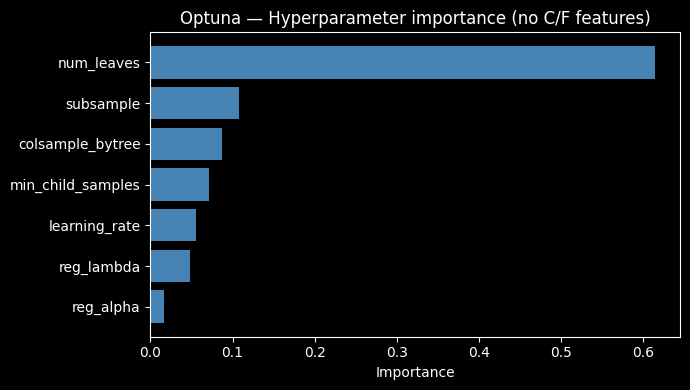

In [6]:
importances = optuna.importance.get_param_importances(study)
print("Parameter importances:")
for k, v in importances.items():
    print(f"  {k:25s}: {v:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(list(importances.keys()), list(importances.values()), color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("Optuna — Hyperparameter importance (no C/F features)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 最終パラメータで 5-fold CV 確認

In [7]:
FINAL_LGBM_PARAMS = {
    "objective":      "regression",
    "metric":         "mae",
    "n_estimators":   1000,
    "subsample_freq": 1,
    **study.best_params,
    "random_state":   RANDOM_STATE,
    "n_jobs":         -1,
    "verbose":        -1,
}

result_rows = []
VALIDATION_RATIO = 0.2

for target, unit in TARGET_COLS.items():
    df_t = features.dropna(subset=[target]).copy()
    feat_cols = get_feat_cols(df_t)
    X_t, y_t = df_t[feat_cols].fillna(0), df_t[target]

    cv_maes = []
    for tr, val in TimeSeriesSplit(n_splits=5).split(X_t):
        m = lgb.LGBMRegressor(**FINAL_LGBM_PARAMS)
        m.fit(
            X_t.iloc[tr], y_t.iloc[tr],
            eval_set=[(X_t.iloc[val], y_t.iloc[val])],
            callbacks=[
                lgb.early_stopping(EARLY_STOPPING, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )
        cv_maes.append(mean_absolute_error(y_t.iloc[val], m.predict(X_t.iloc[val])))

    n = len(df_t)
    split_idx = int(n * (1 - VALIDATION_RATIO))
    final_m = lgb.LGBMRegressor(**FINAL_LGBM_PARAMS)
    final_m.fit(
        X_t.iloc[:split_idx], y_t.iloc[:split_idx],
        eval_set=[(X_t.iloc[split_idx:], y_t.iloc[split_idx:])],
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    val_metrics = metrics(y_t.iloc[split_idx:], final_m.predict(X_t.iloc[split_idx:]))
    baseline_mae = float(y_t.iloc[split_idx:].abs().mean())

    result_rows.append({
        "target":       target,
        "unit":         unit,
        "n_features":   len(feat_cols),
        "cv_mae_mean":  np.mean(cv_maes),
        "cv_mae_std":   np.std(cv_maes),
        "val_mae":      val_metrics["mae"],
        "val_rmse":     val_metrics["rmse"],
        "val_bias":     val_metrics["bias"],
        "baseline_mae": baseline_mae,
        "improvement":  (1 - val_metrics["mae"] / baseline_mae) * 100,
    })
    print(f"[{target}]  cv_mae={np.mean(cv_maes):.4f}  val_mae={val_metrics['mae']:.4f}  baseline={baseline_mae:.4f}")

display(pd.DataFrame(result_rows).set_index("target").round(4))

[temp_error]  cv_mae=0.6629  val_mae=0.6197  baseline=1.1320
[precip_error]  cv_mae=0.1426  val_mae=0.1474  baseline=0.1502
[cloud_error]  cv_mae=18.0939  val_mae=19.2847  baseline=28.8314
[cloud_low_error]  cv_mae=14.9201  val_mae=15.6900  baseline=17.2794


,unit,n_features,cv_mae_mean,cv_mae_std,val_mae,val_rmse,val_bias,baseline_mae,improvement
target,,,,,,,,,
temp_error,℃,95,0.6629,0.0686,0.6197,0.7991,-0.0237,1.1320,45.2622
precip_error,mm,95,0.1426,0.0208,0.1474,0.7215,-0.0226,0.1502,1.8473
cloud_error,%,95,18.0939,2.3257,19.2847,26.7451,0.1511,28.8314,33.1122
cloud_low_error,%,95,14.9201,1.4047,15.6900,24.0998,-0.9455,17.2794,9.1980


## deployment/lgbm_params.json に保存

In [8]:
def _sigfig(x, n=3):
    """浮動小数点を有効数字 n 桁に丸める。"""
    if x == 0 or not isinstance(x, float):
        return x
    d = math.floor(math.log10(abs(x)))
    return round(x, -d + n - 1)


_deployment_dir = next(
    p for p in [Path("../deployment"), Path("deployment")]
    if p.is_dir()
)
_params_path = _deployment_dir / "lgbm_params.json"
_to_save = {
    k: _sigfig(v) if isinstance(v, float) else v
    for k, v in FINAL_LGBM_PARAMS.items()
    if k not in ("n_jobs", "verbose")
}
_params_path.write_text(json.dumps(_to_save, indent=2, ensure_ascii=False))
print(f"LGBM params saved → {_params_path}")
print(json.dumps(_to_save, indent=2))

LGBM params saved → ..\deployment\lgbm_params.json
{
  "objective": "regression",
  "metric": "mae",
  "n_estimators": 1000,
  "subsample_freq": 1,
  "learning_rate": 0.0418,
  "num_leaves": 20,
  "min_child_samples": 34,
  "subsample": 0.734,
  "colsample_bytree": 0.984,
  "reg_alpha": 0.0138,
  "reg_lambda": 0.715,
  "random_state": 42
}
